# Viewing metrics - Descriptive evaluation

Importing libraries

In [2]:
library(readr)
library(dplyr)
library(tidyr)
library(gt)
library(RColorBrewer)
library(scales)
library(ggplot2)
library(stringr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




Broad overview of STR distribution

In [3]:
# CSV import
df_desc_analysis <- read_csv("results/stats_group_repeat_full_metrics.csv")

# Normalizing the Number of Observations by the total number of cases and controls
df_desc_analysis <- df_desc_analysis %>%
  mutate(
    Numero_Observacoes_norm = ifelse(
      group == "case", Number_Observations / 32,
      ifelse(group == "control", Number_Observations / 136, NA)
    )
  )
# Viewing the dataframe
View(df_desc_analysis)


Rows: 2 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): group
dbl (16): Mean_allele1_est, SD_allele1_est, Median_allele1_est, Q1_allele1_e...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


group,Mean_allele1_est,SD_allele1_est,Median_allele1_est,Q1_allele1_est,Q3_allele1_est,Mean_allele2_est,SD_allele2_est,Median_allele2_est,Q1_allele2_est,Q3_allele2_est,Mean_extension_size,SD_extension_size,Median_extension_size,Q1_extension_size,Q3_extension_size,Number_Observations,Numero_Observacoes_norm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
case,1.211872,4.611143,0,0,2.5,26.27680,29.38003,19.60,13.69,28.98,28.89999,29.17858,22.47,15.76,32.19,88501,2765.656
control,1.242356,4.599910,0,0,2.5,25.57592,28.42770,19.32,13.59,28.05,28.19500,28.32454,22.19,15.63,31.30,407343,2995.169


Conversion into a table for publication

In [4]:
# 1. Pivot to long format
df_long <- df_desc_analysis %>%
  pivot_longer(
    cols = -group,
    names_to = "Metric",
    values_to = "valor"
  )

# 2. Translated Metric names with EXACT matches from your image
df_long <- df_long %>%
  mutate(Metric = case_when(
    # Allele 1 (matching lowercase 'a' and '_est')
    Metric == "Mean_allele1_est"   ~ "Mean (Allele 1)",
    Metric == "SD_allele1_est"     ~ "SD (Allele 1)",
    Metric == "Median_allele1_est" ~ "Median (Allele 1)",
    Metric == "Q1_allele1_est"     ~ "Q1 (Allele 1)",
    Metric == "Q3_allele1_est"     ~ "Q3 (Allele 1)",
    
    # Allele 2 (matching lowercase 'a' and '_est')
    Metric == "Mean_allele2_est"   ~ "Mean (Allele 2)",
    Metric == "SD_allele2_est"     ~ "SD (Allele 2)",
    Metric == "Median_allele2_est" ~ "Median (Allele 2)",
    Metric == "Q1_allele2_est"     ~ "Q1 (Allele 2)",
    Metric == "Q3_allele2_est"     ~ "Q3 (Allele 2)",
    
    # Extension Size (matching underscores)
    Metric == "Mean_extension_size"   ~ "Mean (Extension Size)",
    Metric == "SD_extension_size"     ~ "SD (Extension Size)",
    Metric == "Median_extension_size" ~ "Median (Extension Size)",
    Metric == "Q1_extension_size"     ~ "Q1 (Extension Size)",
    Metric == "Q3_extension_size"     ~ "Q3 (Extension Size)",
    
    # Observations
    Metric == "Number_Observations"      ~ "Total Observations",
    Metric == "Numero_Observacoes_norm"  ~ "Normalized Observations",
    
    TRUE ~ Metric
  ))

# 3. Pivot to wide format
df_wide <- df_long %>%
  pivot_wider(
    names_from = group,
    values_from = valor
  ) %>%
  rename(
    'Case Group' = case,
    'Control Group' = control
  )

# 4. Create the table
tabela_gt <- gt(df_wide) %>%
  fmt_number(
    columns = -Metric,      
    decimals = 2,
    use_seps = TRUE           
  ) %>%
  tab_header(
    title = "Descriptive Statistics of STR Metrics",
    subtitle = "Comparison between Case and Control Groups"
  ) %>%
  cols_label(
    Metric = "Metric",
    `Case Group` = "Case Group",
    `Control Group` = "Control Group"
  ) %>%
  tab_footnote(
    footnote = "SD: Standard Deviation; Q1: First Quartile; Q3: Third Quartile",
    locations = cells_column_labels(columns = Metric)
  )

# 5. Save as HTML
gtsave(tabela_gt, "results/table_summary_desc.html")

## Genomic Distribution of Short Tandem Repeats Across Functional Regions

Rows: 495844 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): locus, sample_id, group, region, gene_name, chrom, repeat_unit
dbl (5): start, end, allele1_est, allele2_est, depth

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 8 × 3
  region               n percent
  <fct>            <int>   <dbl>
1 intergenic       15546 40.5   
2 intron           15427 40.1   
3 others            6340 16.5   
4 promoter           624  1.62  
5 three_prime_utr    321  0.835 
6 non_coding_exons    99  0.258 
7 five_prime_utr      61  0.159 
8 CDS                 11  0.0286


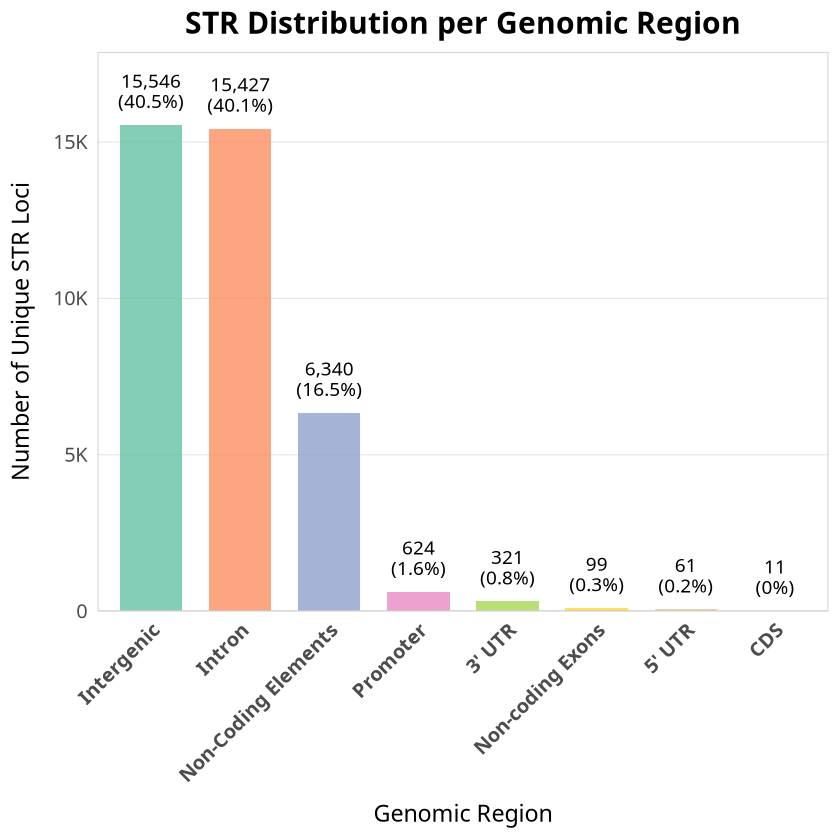

In [5]:
# Read the data
strs_data <- read_csv("results/strs_by_locus_combo.csv")

# Count unique STR loci by region
strs_region_summary <- strs_data %>%
  distinct(locus, region) %>%
  count(region, name = "n") %>%
  mutate(percent = 100 * n / sum(n)) %>%
  arrange(desc(n)) %>%
  mutate(region = factor(region, levels = region))

# View the results
print(strs_region_summary)

# Create the plot
p <- ggplot(strs_region_summary, aes(x = region, y = n, fill = region)) +
  geom_bar(stat = "identity", alpha = 0.8, width = 0.7) +
  geom_text(
    aes(label = paste0(scales::comma(n), "\n(", round(percent, 1), "%)")),
    vjust = -0.5, size = 4, lineheight = 0.9  
  ) +
  labs(
    title = "STR Distribution per Genomic Region",
    x = "Genomic Region",
    y = "Number of Unique STR Loci"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, face = "bold"),
    axis.text.y = element_text(size = 12),
    legend.position = "none",
    axis.title.x = element_text(size = 14, margin = margin(t = 10)),
    axis.title.y = element_text(size = 14, margin = margin(r = 10)),
    panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.5)
  ) +
  scale_y_continuous(
    labels = label_number(scale_cut = cut_short_scale()),  # ALTERADO: K, M format
    expand = expansion(mult = c(0, 0.15))
  ) +
  scale_fill_brewer(palette = "Set2") +
  scale_x_discrete(labels = function(x) {
    case_when(
      x == "five_prime_utr" ~ "5' UTR",
      x == "three_prime_utr" ~ "3' UTR",
      x == "intergenic" ~ "Intergenic",
      x == "intron" ~ "Intron",
      x == "promoter" ~ "Promoter",
      x == "CDS" ~ "CDS",
      x == "others" ~ "Non-Coding Elements",
      x == "non_coding_exons" ~ "Non-coding Exons",
      TRUE ~ x
    )
  })

print(p)

ggsave("results/barplot_region.png", plot = p, width = 10, height = 6, dpi = 600, bg = "white")


# Evaluation of the distribution of the major allele of STRS by region

Overview

In [6]:
strs_region <- read_csv("results/strs_by_region_combo.csv")
df_tibble <- as_tibble(strs_region)
head(strs_region)

Rows: 16 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): region, group
dbl (10): n_per_group, mean_allele1, sd_allele1, min_allele1, max_allele1, m...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


region,group,n_per_group,mean_allele1,sd_allele1,min_allele1,max_allele1,mean_allele2,sd_allele2,min_allele2,max_allele2,total_region
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CDS,case,31,3.967742,4.094581,-1,9.0,16.18161,9.572230,7.74,40.36,158
CDS,control,127,3.186378,4.266590,-4,13.0,14.09543,7.477521,7.50,44.20,158
five_prime_utr,case,156,1.996795,5.023332,-13,16.0,31.36295,18.405743,7.67,104.20,902
five_prime_utr,control,746,1.880697,4.676642,-23,16.0,30.85169,19.895870,7.19,168.10,902
intergenic,case,35221,1.107102,4.562577,-33,22.5,26.46429,27.863208,3.58,361.59,196579
intergenic,control,161358,1.152331,4.551197,-34,21.5,25.67480,26.884723,3.52,364.64,196579


Distribution between genomic regions and groups

Rows: 495844 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): locus, sample_id, group, region, gene_name, chrom, repeat_unit
dbl (5): start, end, allele1_est, allele2_est, depth

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


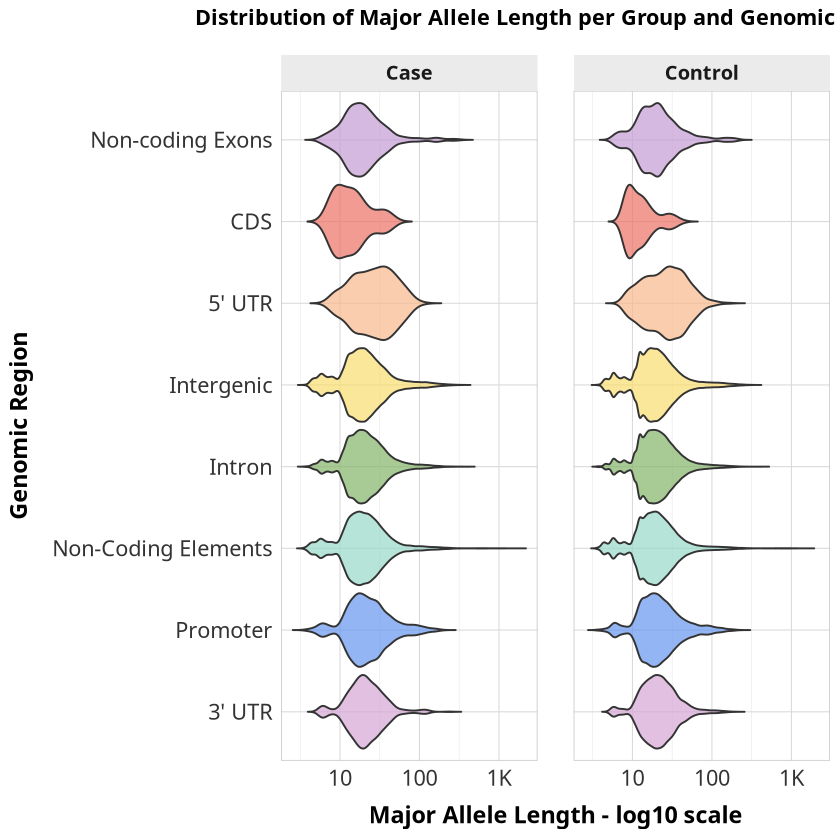

In [7]:
# Read the data
df <- read_csv("results/strs_by_locus_combo.csv")

# Filter out zeros for log transformation and set factor order
df_plot <- df %>%
  mutate(region = factor(region, levels = c(
    "three_prime_utr", "promoter", "others", "intron", 
    "intergenic", "five_prime_utr", "CDS", "non_coding_exons"
  )))

# Create the violin plot with log scale
p <- ggplot(df_plot, aes(x = allele2_est, y = region, fill = region)) +
  # Add violin plot
  geom_violin(trim = FALSE, alpha = 0.7, scale = "width") +
  
  # Log scale for x-axis
  scale_x_log10(
    breaks = c(1, 10, 100, 1000, 10000),
    labels = label_number(scale_cut = cut_short_scale())  # altered to K, M format
  ) +
  
  # Facet by group
  facet_wrap(~ group, ncol = 2,
             labeller = labeller(group = c(case = "Case", control = "Control"))) +
  
  # Set color palette (more vibrant colors)
  scale_fill_manual(values = c(
    "three_prime_utr" = "#D4A5D4",   # light purple
    "promoter" = "#6495ED",          # cornflower blue
    "others" = "#98D8C8",            # turquoise
    "intron" = "#82B366",            # green
    "intergenic" = "#F7DC6F",        # yellow
    "five_prime_utr" = "#F8B88B",    # peach
    "non_coding_exons" = "#C39BD3", # lavender
    "CDS" = "#EC7063"                # coral
  )) +
  
  # Labels in English
  labs(
    title = "Distribution of Major Allele Length per Group and Genomic Region",
    x = "Major Allele Length - log10 scale",
    y = "Genomic Region"
  ) +
  
  # Clean region names for display
  scale_y_discrete(labels = c(
    "three_prime_utr" = "3' UTR",
    "promoter" = "Promoter",
    "others" = "Non-Coding Elements",
    "intron" = "Intron",
    "intergenic" = "Intergenic",
    "five_prime_utr" = "5' UTR",
    "non_coding_exons" = "Non-coding Exons",
    "CDS" = "CDS"
  )) +
  
  # Theme adjustments
  theme_minimal(base_size = 12) +
  theme(
    # Remove legend
    legend.position = "none",
    
    # Grid
    panel.grid.major.x = element_line(color = "grey85", linewidth = 0.3),
    panel.grid.minor.x = element_line(color = "grey92", linewidth = 0.2),
    panel.grid.major.y = element_line(color = "grey85", linewidth = 0.3),
    panel.grid.minor.y = element_blank(),
    
    # Facet strips
    strip.text = element_text(size = 12, face = "bold"),
    strip.background = element_rect(fill = "grey92", color = NA),
    
    # Axes
    axis.text = element_text(size = 13, color = "grey20"),
    axis.text.y = element_text(size = 13),
    axis.title = element_text(size = 14, face = "bold"),
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 10)),
    
    # Plot title
    plot.title = element_text(size = 13, hjust = 0.5, face = "bold", 
                              margin = margin(b = 15)),
    
    # Background
    panel.background = element_rect(fill = "white", color = NA),
    plot.background = element_rect(fill = "white", color = NA),
    
    # Panel spacing and border
    panel.spacing = unit(1.5, "lines"),
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.5)
  )

# Display the plot
print(p)

# Save the plot
ggsave("results/violin_plot_allele_distribution_log.png", 
       plot = p, 
       width = 12, 
       height = 7, 
       dpi = 600, 
       bg = "white")


Complementary table to supplementar section

In [8]:
# Read the data
df_table <- read_csv("results/strs_by_locus_combo.csv")

# Calculate descriptive statistics by region and group
summary_stats <- df_table %>%
  group_by(region, group) %>%
  summarise(
    N = n(),
    Mean = mean(allele2_est, na.rm = TRUE),
    SD = sd(allele2_est, na.rm = TRUE),
    Median = median(allele2_est, na.rm = TRUE),
    Q1 = quantile(allele2_est, 0.25, na.rm = TRUE),
    Q3 = quantile(allele2_est, 0.75, na.rm = TRUE),
    Min = min(allele2_est, na.rm = TRUE),
    Max = max(allele2_est, na.rm = TRUE),
    .groups = "drop"
  )

# Pivot to wide format for comparison
summary_wide <- summary_stats %>%
  pivot_longer(
    cols = c(N, Mean, SD, Median, Q1, Q3, Min, Max),
    names_to = "Metric",
    values_to = "value"
  ) %>%
  pivot_wider(
    names_from = group,
    values_from = value
  ) %>%
  rename(
    'Genomic Region' = region,
    'Case' = case,
    'Control' = control
  ) %>%
  mutate(
    `Genomic Region` = case_when(
      `Genomic Region` == "CDS" ~ "CDS",
      `Genomic Region` == "five_prime_utr" ~ "5' UTR",
      `Genomic Region` == "intergenic" ~ "Intergenic",
      `Genomic Region` == "intron" ~ "Intron",
      `Genomic Region` == "others" ~ "Others",
      `Genomic Region` == "promoter" ~ "Promoter",
      `Genomic Region` == "non_coding_exons" ~ "Non-coding Exons",
      `Genomic Region` == "three_prime_utr" ~ "3' UTR",
      TRUE ~ `Genomic Region`
    ),
    Metric = factor(Metric, levels = c("N", "Mean", "SD", "Median", "Q1", "Q3", "Min", "Max"))
  ) %>%
  arrange(`Genomic Region`, Metric)

# Create publication-ready table
table_gt <- summary_wide %>%
  gt(groupname_col = "Genomic Region") %>%
  
  # Format numbers - N as integer
  fmt_number(
    columns = c(Case, Control),
    rows = Metric == "N",
    decimals = 0,
    use_seps = TRUE
  ) %>%
  
  # Format other metrics with 2 decimals
  fmt_number(
    columns = c(Case, Control),
    rows = Metric != "N",
    decimals = 2,
    use_seps = TRUE
  ) %>%
  
  # Column labels
  cols_label(
    Metric = "Metric",
    Case = "Case",
    Control = "Control"
  ) %>%
  
  # Add title and subtitle
  tab_header(
    title = "Descriptive Statistics of Major Allele Size by Genomic Region",
    subtitle = "Comparison between Case and Control Groups"
  ) %>%
  
  # Add footnote
  tab_footnote(
    footnote = "SD: Standard Deviation; Q1: First Quartile; Q3: Third Quartile",
    locations = cells_column_labels(columns = Metric)
  ) %>%
  
  # Style the table
  tab_style(
    style = cell_text(weight = "bold"),
    locations = cells_row_groups()
  ) %>%
  
  tab_style(
    style = cell_fill(color = "grey95"),
    locations = cells_row_groups()
  ) %>%
  
  # Style column labels
  tab_style(
    style = cell_text(weight = "bold"),
    locations = cells_column_labels()
  ) %>%
  
  # Add borders
  tab_options(
    table.border.top.style = "solid",
    table.border.bottom.style = "solid",
    heading.border.bottom.style = "solid",
    column_labels.border.top.style = "solid",
    column_labels.border.bottom.style = "solid",
    table_body.border.bottom.style = "solid",
    row_group.border.top.style = "solid",
    row_group.border.bottom.style = "solid"
  )

# Save as HTML
gtsave(table_gt, "results/table_allele_stats_by_region.html")

# Save raw data as CSV
write_csv(summary_wide, "results/table_allele_stats_by_region.csv")


Rows: 495844 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): locus, sample_id, group, region, gene_name, chrom, repeat_unit
dbl (5): start, end, allele1_est, allele2_est, depth

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [14]:
# ==========================================
# Tabela unica transposta: Overall + por regiao
# ==========================================
# Reutiliza o df_table ja carregado acima
region_stats <- df_table %>%
  group_by(region, group) %>%
  summarise(
    N      = n(),
    Mean   = mean(allele2_est, na.rm = TRUE),
    SD     = sd(allele2_est, na.rm = TRUE),
    Median = median(allele2_est, na.rm = TRUE),
    Q1     = quantile(allele2_est, 0.25, na.rm = TRUE),
    Q3     = quantile(allele2_est, 0.75, na.rm = TRUE),
    Min    = min(allele2_est, na.rm = TRUE),
    Max    = max(allele2_est, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    region = case_when(
      region == "CDS"              ~ "CDS",
      region == "five_prime_utr"   ~ "5' UTR",
      region == "three_prime_utr"  ~ "3' UTR",
      region == "intergenic"       ~ "Intergenic",
      region == "intron"           ~ "Intron",
      region == "promoter"         ~ "Promoter",
      region == "non_coding_exons" ~ "Non-coding Exons",
      region == "others"           ~ "Others",
      TRUE ~ region
    )
  )
overall_stats <- df_table %>%
  group_by(group) %>%
  summarise(
    N      = n(),
    Mean   = mean(allele2_est, na.rm = TRUE),
    SD     = sd(allele2_est, na.rm = TRUE),
    Median = median(allele2_est, na.rm = TRUE),
    Q1     = quantile(allele2_est, 0.25, na.rm = TRUE),
    Q3     = quantile(allele2_est, 0.75, na.rm = TRUE),
    Min    = min(allele2_est, na.rm = TRUE),
    Max    = max(allele2_est, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(region = "Overall")
all_stats <- bind_rows(overall_stats, region_stats)
wide_case <- all_stats %>%
  filter(group == "case") %>%
  select(-group) %>%
  rename_with(~ paste0(.x, "_Case"), -c(region))
wide_control <- all_stats %>%
  filter(group == "control") %>%
  select(-group) %>%
  rename_with(~ paste0(.x, "_Control"), -c(region))
merged <- full_join(wide_case, wide_control, by = "region") %>%
  select(
    region,
    N_Case, N_Control,
    Mean_Case, Mean_Control,
    SD_Case, SD_Control,
    Median_Case, Median_Control,
    Q1_Case, Q1_Control,
    Q3_Case, Q3_Control,
    Min_Case, Min_Control,
    Max_Case, Max_Control
  ) %>%
  mutate(region = factor(region, levels = c(
    "Overall", "Promoter", "5' UTR", "CDS", "3' UTR",
    "Intron", "Non-coding Exons", "Intergenic", "Others"
  ))) %>%
  arrange(region)
gt_merged <- merged %>%
  gt(rowname_col = "region") %>%
  tab_spanner(label = html("<b>Case</b>"), columns = ends_with("_Case")) %>%
  tab_spanner(label = html("<b>Control</b>"), columns = ends_with("_Control")) %>%
  cols_label(
    N_Case = "N", N_Control = "N",
    Mean_Case = "Mean", Mean_Control = "Mean",
    SD_Case = "SD", SD_Control = "SD",
    Median_Case = "Median", Median_Control = "Median",
    Q1_Case = "Q1", Q1_Control = "Q1",
    Q3_Case = "Q3", Q3_Control = "Q3",
    Min_Case = "Min", Min_Control = "Min",
    Max_Case = "Max", Max_Control = "Max"
  ) %>%
  fmt_number(
    columns = where(is.numeric) & !c(N_Case, N_Control),
    decimals = 2, use_seps = TRUE
  ) %>%
  fmt_number(columns = c(N_Case, N_Control), decimals = 0, use_seps = TRUE) %>%
  tab_header(
    title = md("**Descriptive Statistics of Major Allele Length**"),
  ) %>%
  tab_footnote(
    footnote = "SD: Standard Deviation; Q1: First Quartile; Q3: Third Quartile",
    locations = cells_column_labels(columns = c(SD_Case, SD_Control))
  ) %>%
  tab_style(style = cell_text(weight = "bold"), locations = cells_column_labels()) %>%
  tab_style(style = cell_text(weight = "bold"), locations = cells_row_groups()) %>%
  tab_style(style = cell_fill(color = "grey95"), locations = cells_row_groups()) %>%
  tab_options(
    table.font.size = px(13),
    table.width = pct(100),
    heading.align = "center",
    heading.title.font.size = px(16),
    heading.subtitle.font.size = px(12),
    column_labels.font.weight = "bold",
    column_labels.border.top.style = "solid",
    column_labels.border.bottom.style = "solid",
    table.border.top.style = "solid",
    table.border.bottom.style = "solid",
    table_body.border.bottom.style = "solid",
    row_group.border.top.style = "solid",
    row_group.border.bottom.style = "solid",
    data_row.padding = px(5)
  )
gtsave(gt_merged, "results/table_allele_stats_merged.html")
write_csv(merged, "results/table_allele_stats_merged.csv")
cat("Tabela mesclada salva em results/table_allele_stats_merged.html\n")

Tabela mesclada salva em results/table_allele_stats_merged.html


# Genomic Distribution of Short Tandem Repeats Across Chromossomes


In [10]:
strs_RU <- read_csv("results/strs_by_repeatunit_combo.csv")
df_tibble <- as_tibble(strs_RU)
head(strs_RU) 

Rows: 170 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): repeat_unit, groups_present
dbl (3): n_case, n_control, total

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


repeat_unit,n_case,n_control,total,groups_present
<chr>,<dbl>,<dbl>,<dbl>,<chr>
AT,34182,151700,185882,"case, control"
AC,16817,80590,97407,"case, control"
GT,16850,80319,97169,"case, control"
CT,4223,20129,24352,"case, control"
AG,3807,18554,22361,"case, control"
CTTT,893,4154,5047,"case, control"


Rows: 495844 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): locus, sample_id, group, region, gene_name, chrom, repeat_unit
dbl (5): start, end, allele1_est, allele2_est, depth

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


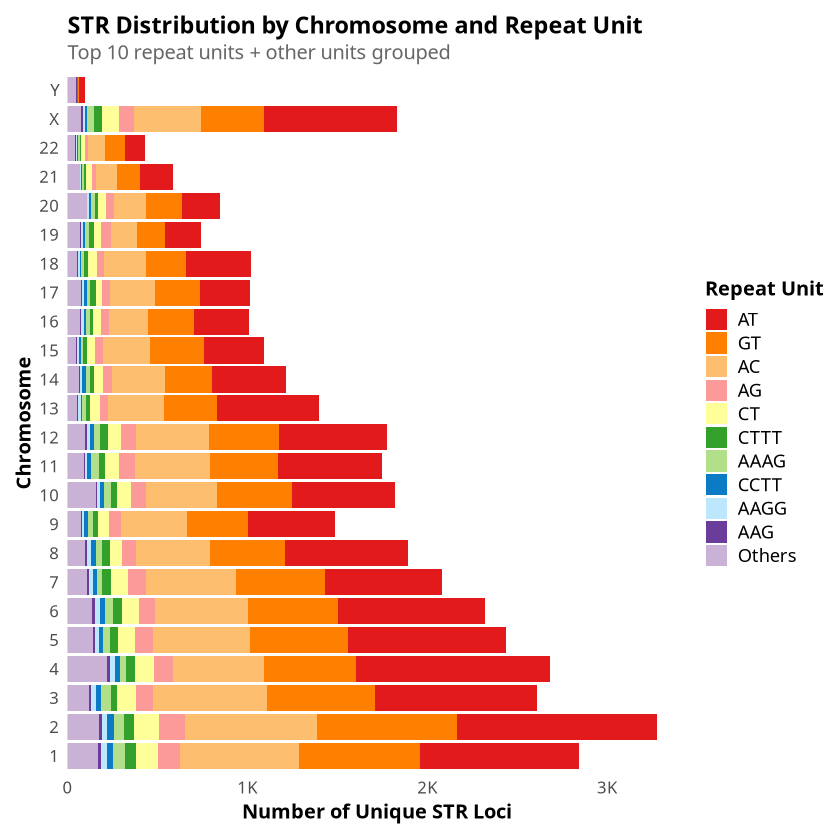

In [11]:
# Read data
strs_data <- read_csv("results/strs_by_locus_combo.csv")

# Count unique STR loci by chromosome and repeat unit
strs_chrom <- strs_data %>%
  distinct(locus, chrom, repeat_unit) %>%
  count(chrom, repeat_unit, name = "n")

# Filter only chromosomes 1-22 + X, Y
desired_chromosomes <- c(1:22, "X", "Y") %>% as.character()

# Adjust and order chromosomes for plotting
strs_chrom <- strs_chrom %>%
  filter(chrom %in% desired_chromosomes) %>%
  mutate(
    chrom = factor(chrom, levels = desired_chromosomes)
  )

# Group repeat units - keep top N and group others
top_repeat_units <- strs_chrom %>%
  group_by(repeat_unit) %>%
  summarise(total = sum(n)) %>%
  arrange(desc(total))

# Define how many units to keep (adjust as needed)
n_to_keep <- 10
units_to_keep <- top_repeat_units$repeat_unit[1:n_to_keep]

# Define colors to be used in the plot
RU_colors <- c('#e31a1c', '#ff7f00', '#fdbf6f', '#fb9a99', '#ffff99',
               '#33a02c', '#b2df8a', '#0b7bc5', '#bce7fd', 
               '#6a3d9a', '#cab2d6')

# Apply grouping
strs_chrom_grouped <- strs_chrom %>%
  mutate(
    repeat_unit_grouped = ifelse(
      repeat_unit %in% units_to_keep,  # CORRIGIDO: era unidades_manter
      as.character(repeat_unit), 
      "Others"
    )
  ) %>%
  # Ensure "Others" is the last level
  mutate(
    repeat_unit_grouped = factor(
      repeat_unit_grouped, 
      levels = c(units_to_keep, "Others")
    )
  )

# Create complete grid with only desired chromosomes
all_chromosomes <- expand.grid(
  chrom = factor(desired_chromosomes, levels = desired_chromosomes),
  repeat_unit_grouped = levels(strs_chrom_grouped$repeat_unit_grouped)
)

# Ensure complete dataframe filling zeros where there is no data
df_complete <- all_chromosomes %>%
  left_join(strs_chrom_grouped, by = c("chrom", "repeat_unit_grouped")) %>%
  mutate(n = ifelse(is.na(n), 0, n)) %>%
  # Group by chrom and repeat_unit_grouped to sum n
  group_by(chrom, repeat_unit_grouped) %>%
  summarise(n = sum(n), .groups = "drop")

# FUNCTION TO FORMAT NUMBERS IN K/M
format_number <- function(x) {
  case_when(
    x >= 1e6 ~ paste0(round(x/1e6, 1), "M"),
    x >= 1e3 ~ paste0(round(x/1e3, 1), "K"),
    TRUE ~ as.character(x)
  )
}

# Create horizontal stacked bar plot WITH LEGEND ON THE RIGHT
p <- ggplot(df_complete, aes(x = chrom, y = n, fill = repeat_unit_grouped)) +
  geom_col() +
  coord_flip() +
  scale_x_discrete(drop = FALSE) +
  scale_fill_manual(values = RU_colors, drop = FALSE) +
  # FORMAT Y-AXIS IN K/M
  scale_y_continuous(
    labels = function(x) format_number(x),
    expand = expansion(mult = c(0, 0.05))
  ) +
  labs(
    title = "STR Distribution by Chromosome and Repeat Unit",
    subtitle = paste("Top", n_to_keep, "repeat units + other units grouped"),  # CORRIGIDO: era n_manter
    x = "Chromosome",
    y = "Number of Unique STR Loci",
    fill = "Repeat Unit"
  ) +
  theme_minimal() +
  theme(
    # LEGEND ON THE RIGHT
    legend.position = "right",
    legend.direction = "vertical",
    legend.title = element_text(size = 12, face = "bold"),
    legend.text = element_text(size = 11),
    legend.key.size = unit(0.6, "lines"),
    legend.key.height = unit(0.5, "cm"),
    legend.key.width = unit(0.5, "cm"),
    legend.margin = margin(0, 0, 0, 0),
    legend.spacing.y = unit(0.1, "cm"),
    
    # ADJUST MARGINS TO COMPENSATE FOR LEGEND
    plot.margin = margin(10, 10, 10, 10),
    plot.title = element_text(size = 14, face = "bold", margin = margin(b = 3)),
    plot.subtitle = element_text(size = 12, color = "gray40", margin = margin(b = 5)),
    
    # REMOVE GRIDLINES
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    
    # Axis elements
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 12, face = "bold"),
    
    # Clean background
    panel.background = element_rect(fill = "white", color = NA),
    plot.background = element_rect(fill = "white", color = NA)
  ) +
  guides(fill = guide_legend(
    ncol = 1,           # One column for vertical legend
    byrow = TRUE,
    label.position = "right"
  ))

print(p)

# SAVE THE PLOT
ggsave("results/barplot_chromosome_repeat_unit.png", 
       plot = p,
       width = 14,
       height = 8,
       dpi = 600,
       bg = "white")


Rows: 495844 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): locus, sample_id, group, region, gene_name, chrom, repeat_unit
dbl (5): start, end, allele1_est, allele2_est, depth

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 455 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): chr
dbl (1): size

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


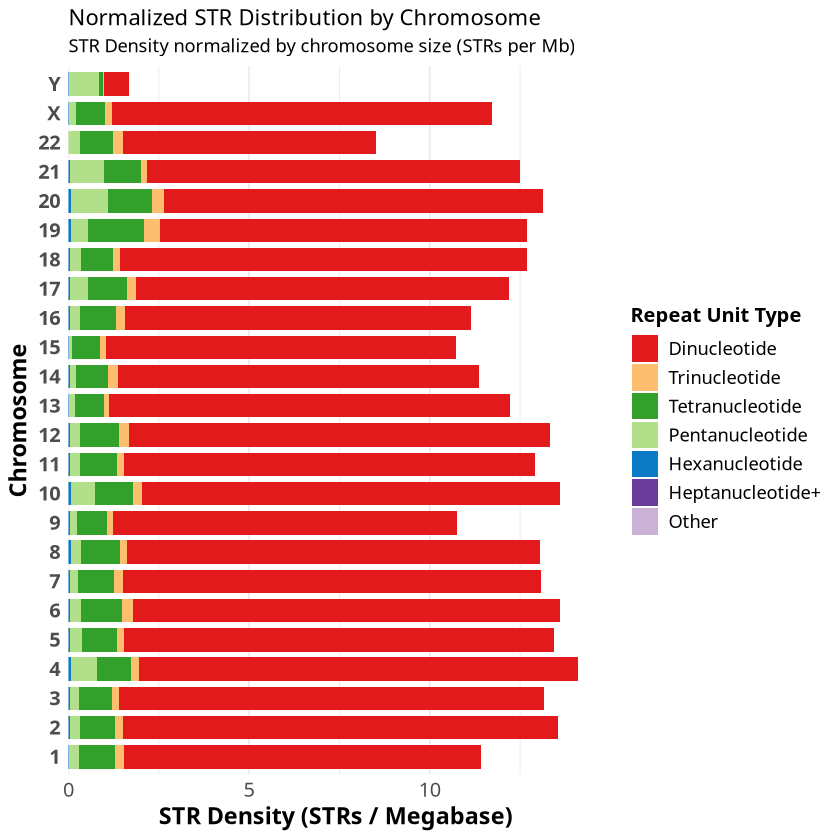

In [12]:
# ==========================================
# DATA LOADING AND PREPARATION
# ==========================================
# Load your locus combo data
strs_data <- read_csv("results/strs_by_locus_combo.csv")

# Load genome sizes (genome.txt)
genome_sizes <- read_tsv("genome.txt", col_names = c("chr", "size"))

# Clean chromosome names and filter
genome_sizes_clean <- genome_sizes %>%
  # Handles both 'chr1' and '1' formats
  mutate(chrom = str_remove(chr, "^chr")) %>%
  filter(chrom %in% c(as.character(1:22), "X", "Y")) %>%
  select(chrom, size)

# Define the correct biological order (1 -> Y)
# Since we use coord_flip, the last item (Y) will appear at the top of the plot
biological_order <- c(as.character(1:22), "X", "Y")

# ==========================================
# DATA PROCESSING
# ==========================================
df_plot <- strs_data %>%
  distinct(locus, chrom, repeat_unit) %>%
  mutate(
    repeat_type = case_when(
      nchar(repeat_unit) == 2 ~ "Dinucleotide",
      nchar(repeat_unit) == 3 ~ "Trinucleotide",
      nchar(repeat_unit) == 4 ~ "Tetranucleotide",
      nchar(repeat_unit) == 5 ~ "Pentanucleotide",
      nchar(repeat_unit) == 6 ~ "Hexanucleotide",
      nchar(repeat_unit) >= 7 ~ "Heptanucleotide+",
      TRUE ~ "Other"
    )
  ) %>%
  count(chrom, repeat_type, name = "n") %>%
  # Normalization to STRs per Megabase (Mb)
  left_join(genome_sizes_clean, by = "chrom") %>%
  mutate(n_normalized = (n / size) * 1e6) 

# COMPLETE GRID (Ensures chromosomes missing certain STRs appear as zero)
repeat_levels <- c("Dinucleotide", "Trinucleotide", 
                   "Tetranucleotide", "Pentanucleotide", "Hexanucleotide", 
                   "Heptanucleotide+", "Other")

df_complete <- expand.grid(
  chrom = biological_order,
  repeat_type = repeat_levels
) %>%
  left_join(df_plot, by = c("chrom", "repeat_type")) %>%
  mutate(
    n_normalized = ifelse(is.na(n_normalized), 0, n_normalized),
    # FIXED CHROMOSOME ORDER:
    chrom = factor(chrom, levels = biological_order),
    repeat_type = factor(repeat_type, levels = repeat_levels)
  )

# ==========================================
# FINAL PLOTTING
# ==========================================
repeat_colors <- c(
  "Dinucleotide" = "#e31a1c", 
  "Trinucleotide" = "#fdbf6f", "Tetranucleotide" = "#33a02c", 
  "Pentanucleotide" = "#b2df8a", "Hexanucleotide" = "#0b7bc5", 
  "Heptanucleotide+" = "#6a3d9a", "Other" = "#cab2d6"
)

p <- ggplot(df_complete, aes(x = chrom, y = n_normalized, fill = repeat_type)) +
  geom_col(width = 0.8) +
  coord_flip() +
  scale_x_discrete(drop = FALSE) + 
  scale_fill_manual(values = repeat_colors) +
  # Friendly X-axis (Density)
  scale_y_continuous(
    labels = label_comma(), 
    expand = expansion(mult = c(0, 0.05))
  ) +
  labs(
    title = "Normalized STR Distribution by Chromosome",
    subtitle = "STR Density normalized by chromosome size (STRs per Mb)",
    x = "Chromosome",
    y = "STR Density (STRs / Megabase)",
    fill = "Repeat Unit Type"
  ) +
  theme_minimal() +
  theme(
    axis.text = element_text(size = 12),
    axis.text.y = element_text(face = "bold", size = 12),
    axis.title = element_text(face = "bold", size = 14),
    panel.grid.major.y = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 12, face = "bold"),
    legend.text = element_text(size = 11)
)

print(p)

# Save with high resolution
ggsave("results/barplot_STR_distribution.png", 
       plot = p, 
       width = 10, 
       height = 10, 
       dpi = 600,
       bg = "white")

In [16]:
# Read the data
strs_data <- read_csv("results/strs_by_locus_combo.csv")
strs_repeat_summary <- read_csv("results/strs_by_repeatunit_combo.csv")

# Read chromosome sizes
genome_sizes <- read_tsv("genome.txt", col_names = c("chr", "size"))

# Prepare chromosome sizes
genome_sizes_clean <- genome_sizes %>%
  filter(str_detect(chr, "^chr[0-9XY]+$")) %>%
  mutate(chrom = str_remove(chr, "^chr")) %>%
  select(chrom, size)

# Calculate total genome size (chr 1-22, X, Y)
cromossomos_desejados <- c(as.character(1:22), "X", "Y")  # Order: 1-22, then X, Y
genome_total_size <- genome_sizes_clean %>%
  filter(chrom %in% cromossomos_desejados) %>%
  summarise(total_size = sum(size)) %>%
  pull(total_size)

# Identify top 5 repeat units
top5_repeats <- strs_repeat_summary %>%
  arrange(desc(total)) %>%
  head(5) %>%
  pull(repeat_unit)

# Count unique STRs by chromosome and repeat unit (top 5 only)
strs_chrom_repeat <- strs_data %>%
  filter(repeat_unit %in% top5_repeats) %>%
  distinct(locus, chrom, repeat_unit) %>%
  count(chrom, repeat_unit, name = "n_loci")

# Filter main chromosomes and set factor levels for proper ordering
strs_chrom_repeat <- strs_chrom_repeat %>%
  filter(chrom %in% cromossomos_desejados) %>%
  mutate(chrom = factor(chrom, levels = cromossomos_desejados))

# Join with sizes and normalize
strs_table <- strs_chrom_repeat %>%
  left_join(genome_sizes_clean, by = "chrom") %>%
  mutate(
    density_per_mb = (n_loci / size) * 1e6  # STRs per Mb
  )

# Create pivot table for each repeat unit
table_list <- list()

for(ru in top5_repeats) {
  temp_table <- strs_table %>%
    filter(repeat_unit == ru) %>%
    select(chrom, n_loci, density_per_mb) %>%
    rename(
      Chromosome = chrom,
      !!paste0("Count_", ru) := n_loci,
      !!paste0("Density_", ru) := density_per_mb
    )
  
  table_list[[ru]] <- temp_table
}

# Join all tables
final_table <- table_list[[1]]
for(i in 2:length(table_list)) {
  final_table <- full_join(final_table, table_list[[i]], by = "Chromosome")
}

# Reorganize columns alternating Count and Density for each repeat unit
col_order <- c("Chromosome")
for(ru in top5_repeats) {
  col_order <- c(col_order, paste0("Count_", ru), paste0("Density_", ru))
}

final_table <- final_table %>%
  select(all_of(col_order)) %>%
  # Ensure proper chromosome ordering
  mutate(Chromosome = factor(Chromosome, levels = cromossomos_desejados)) %>%
  arrange(Chromosome)

# Add total row
total_row <- strs_table %>%
  group_by(repeat_unit) %>%
  summarise(
    total_count = sum(n_loci),
    avg_density = sum(n_loci) / genome_total_size * 1e6
  )

totals <- tibble(Chromosome = "Total")
for(ru in top5_repeats) {
  ru_total <- total_row %>% filter(repeat_unit == ru)
  totals[[paste0("Count_", ru)]] <- ru_total$total_count
  totals[[paste0("Density_", ru)]] <- ru_total$avg_density
}

# Reorder top5_repeats by filtered totals (descending)
total_counts <- sapply(top5_repeats, function(ru) totals[[paste0("Count_", ru)]])
top5_repeats <- top5_repeats[order(total_counts, decreasing = TRUE)]

# Rebuild final_table with corrected order
table_list <- list()
for(ru in top5_repeats) {
  temp_table <- strs_table %>%
    filter(repeat_unit == ru) %>%
    select(chrom, n_loci, density_per_mb) %>%
    rename(
      Chromosome = chrom,
      !!paste0("Count_", ru) := n_loci,
      !!paste0("Density_", ru) := density_per_mb
    )
  table_list[[ru]] <- temp_table
}
final_table <- table_list[[1]]
for(i in 2:length(table_list)) {
  final_table <- full_join(final_table, table_list[[i]], by = "Chromosome")
}
col_order <- c("Chromosome")
for(ru in top5_repeats) {
  col_order <- c(col_order, paste0("Count_", ru), paste0("Density_", ru))
}
final_table <- final_table %>%
  select(all_of(col_order)) %>%
  mutate(Chromosome = factor(Chromosome, levels = cromossomos_desejados)) %>%
  arrange(Chromosome)

# Convert Chromosome back to character before binding
final_table <- final_table %>%
  mutate(Chromosome = as.character(Chromosome))

final_table <- bind_rows(final_table, totals)

# Create GT publication-ready table
table_gt <- final_table %>%
  gt() %>%
  
  # Add spanners for each repeat unit
  tab_spanner(
    label = md(paste0("**", top5_repeats[1], "**")),
    columns = c(paste0("Count_", top5_repeats[1]), paste0("Density_", top5_repeats[1]))
  ) %>%
  tab_spanner(
    label = md(paste0("**", top5_repeats[2], "**")),
    columns = c(paste0("Count_", top5_repeats[2]), paste0("Density_", top5_repeats[2]))
  ) %>%
  tab_spanner(
    label = md(paste0("**", top5_repeats[3], "**")),
    columns = c(paste0("Count_", top5_repeats[3]), paste0("Density_", top5_repeats[3]))
  ) %>%
  tab_spanner(
    label = md(paste0("**", top5_repeats[4], "**")),
    columns = c(paste0("Count_", top5_repeats[4]), paste0("Density_", top5_repeats[4]))
  ) %>%
  tab_spanner(
    label = md(paste0("**", top5_repeats[5], "**")),
    columns = c(paste0("Count_", top5_repeats[5]), paste0("Density_", top5_repeats[5]))
  ) %>%
  
  # Rename columns to Count and Density
  cols_label(
    .list = setNames(
      rep(c("Count", "Density (per Mb)"), 5),
      unlist(lapply(top5_repeats, function(ru) c(paste0("Count_", ru), paste0("Density_", ru))))
    )
  ) %>%
  
  # Format numbers - Count as integer
  fmt_number(
    columns = starts_with("Count_"),
    decimals = 0,
    use_seps = TRUE
  ) %>%
  
  # Format Density with 2 decimals
  fmt_number(
    columns = starts_with("Density_"),
    decimals = 2,
    use_seps = TRUE
  ) %>%
  
  # Title
  tab_header(
    title = md("**STR Distribution and Density per Chromosome**"),
    subtitle = "Top 5 most abundant repeat units with absolute counts and density per megabase"
  ) %>%
  
  # Footnote
  tab_footnote(
    footnote = "Density calculated as number of unique STR loci per megabase (Mb) of chromosome length",
    locations = cells_column_labels(columns = starts_with("Density_"))
  ) %>%
  
  # Style Total row
  tab_style(
    style = list(
      cell_fill(color = "grey90"),
      cell_text(weight = "bold")
    ),
    locations = cells_body(rows = Chromosome == "Total")
  ) %>%
  
  # Style header
  tab_style(
    style = cell_text(weight = "bold"),
    locations = cells_column_labels()
  ) %>%
  
  # Borders
  tab_options(
    table.font.size = px(13),
    table.width = pct(100),
    heading.align = "center",
    heading.title.font.size = px(16),
    heading.subtitle.font.size = px(12),
    column_labels.font.weight = "bold",
    column_labels.border.top.style = "solid",
    column_labels.border.bottom.style = "solid",
    table.border.top.style = "solid",
    table.border.bottom.style = "solid",
    table_body.border.bottom.style = "solid",
    data_row.padding = px(5)
  )


# Save HTML
gtsave(table_gt, "results/supplementary_table_str_density_top5.html")

# Save CSV
write_csv(final_table, "results/supplementary_table_str_density_top5.csv")

# Print summary
cat("\nTop 5 Repeat Units:\n")
print(strs_repeat_summary %>% head(5) %>% select(repeat_unit, total))
cat("\nTotal genome size (chr 1-22, X, Y):", format(genome_total_size, big.mark = ","), "bp\n")


Rows: 495844 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): locus, sample_id, group, region, gene_name, chrom, repeat_unit
dbl (5): start, end, allele1_est, allele2_est, depth

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 170 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): repeat_unit, groups_present
dbl (3): n_case, n_control, total

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 455 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): chr
dbl (1): size

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `sho


Top 5 Repeat Units:
# A tibble: 5 × 2
  repeat_unit  total
  <chr>        <dbl>
1 AT          185882
2 AC           97407
3 GT           97169
4 CT           24352
5 AG           22361

Total genome size (chr 1-22, X, Y): 3,088,269,832 bp
